In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [8]:
# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [9]:
# 2. Load Data
customers = pd.read_csv('Customer_Information.csv')
menu = pd.read_excel('Menu_Information.xlsx', sheet_name='Menu_Items')
orders = pd.read_excel('Order_Information.xlsx', sheet_name='Orders_Q2_2025')
loyalty = pd.read_excel('Loyalty_Campaign_Information.xlsx', sheet_name='Loyalty_Campaign')

In [12]:
# 3. Data Cleaning
# ---- Customers ----
# Check missing values
print(customers.isnull().sum())
# Age: fill missing with median? For analysis, we can drop or impute.
# Membership_Tier: fill missing with 'Standard' (most common) or leave as 'Unknown'.
customers['Age'].fillna(customers['Age'].median(),)
customers['Membership_Tier'].fillna('Standard')
# Convert Join_Date to datetime
customers['Join_Date'] = pd.to_datetime(customers['Join_Date'])

# ---- Orders ----
# Total_Amount_INR has some missing values (e.g., ORD00001 row 3). Compute from Subtotal - Discount.
orders['Total_Amount_INR'] = orders['Total_Amount_INR'].fillna(
    orders['Subtotal_INR'] - orders['Discount_Amount_INR']
)
# Ensure Discount_% is numeric (some are strings like '33.3')
orders['Discount_%'] = pd.to_numeric(orders['Discount_%'], errors='coerce').fillna(0)
# Customer_Rating missing -> fill with 0 or leave as NaN for analysis
orders['Customer_Rating'] = orders['Customer_Rating'].fillna(0)
# Order_Date to datetime
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])
# Filter Q2 2025 (April, May, June)
orders_q2 = orders[(orders['Order_Date'].dt.month >= 4) & (orders['Order_Date'].dt.month <= 6)]

# ---- Menu - no missing values except Calories for Merchandise ----
menu['Calories'] = menu['Calories'].fillna(0)

# ---- Loyalty - all dates are 2024-12-20, expiry 2025-01-31. No cleaning needed.
loyalty['Campaign_Date'] = pd.to_datetime(loyalty['Campaign_Date'])
loyalty['Expiry_Date'] = pd.to_datetime(loyalty['Expiry_Date'])

Customer_ID        0
Customer_Name      0
Email              0
Gender             0
Age                0
City               0
Region             0
Membership_Tier    0
Join_Date          0
dtype: int64


Unique customers in Q2 2025: 200
Average spend per customer in Q2: INR 4901.28


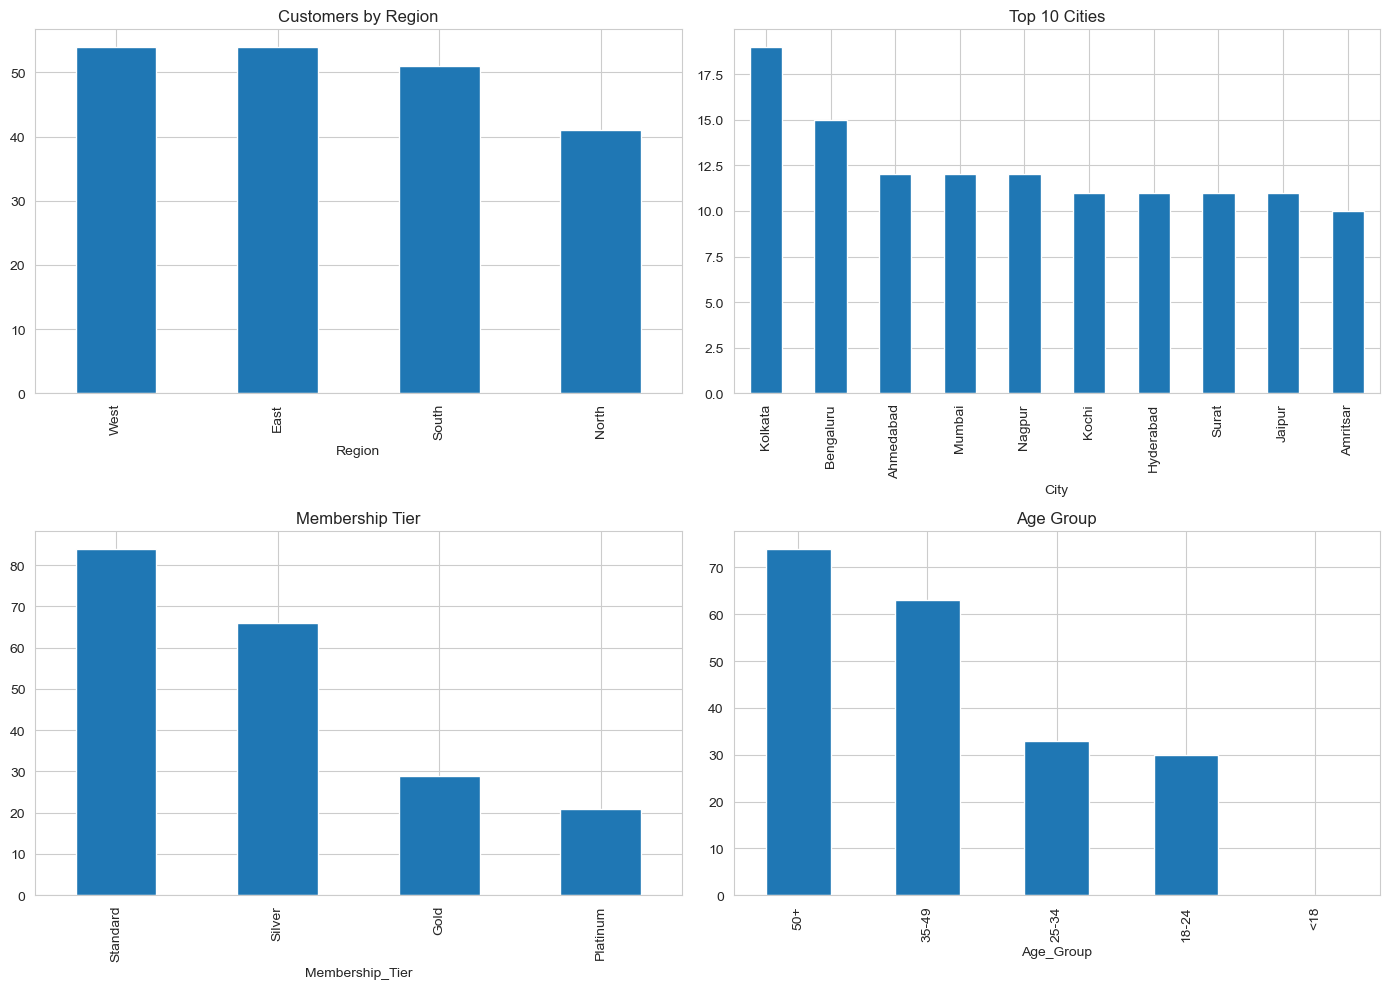

In [13]:
# 4. Customer Analysis
# 4.1 Unique customers in Q2
unique_customers = orders_q2['Customer_ID'].nunique()
print(f"Unique customers in Q2 2025: {unique_customers}")

# 4.2 Distributions
# Region
region_dist = customers['Region'].value_counts()
# City
city_dist = customers['City'].value_counts().head(10)
# Membership Tier
tier_dist = customers['Membership_Tier'].value_counts()
# Age groups
bins = [0, 18, 25, 35, 50, 100]
labels = ['<18', '18-24', '25-34', '35-49', '50+']
customers['Age_Group'] = pd.cut(customers['Age'], bins=bins, labels=labels, right=False)
age_dist = customers['Age_Group'].value_counts()

# 4.3 Average spend per customer
# Sum total amount per order line (but each order has multiple lines, we need per order total)
order_totals = orders_q2.groupby('Order_ID')['Total_Amount_INR'].sum().reset_index()
order_totals_with_cust = orders_q2[['Order_ID', 'Customer_ID']].drop_duplicates().merge(order_totals, on='Order_ID')
customer_spend = order_totals_with_cust.groupby('Customer_ID')['Total_Amount_INR'].sum()
avg_spend_per_customer = customer_spend.mean()
print(f"Average spend per customer in Q2: INR {avg_spend_per_customer:.2f}")

# Visualization: Bar charts for distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
region_dist.plot(kind='bar', ax=axes[0,0], title='Customers by Region')
city_dist.plot(kind='bar', ax=axes[0,1], title='Top 10 Cities')
tier_dist.plot(kind='bar', ax=axes[1,0], title='Membership Tier')
age_dist.plot(kind='bar', ax=axes[1,1], title='Age Group')
plt.tight_layout()
plt.show()


Total revenue Q2 2025: INR 980,255.10


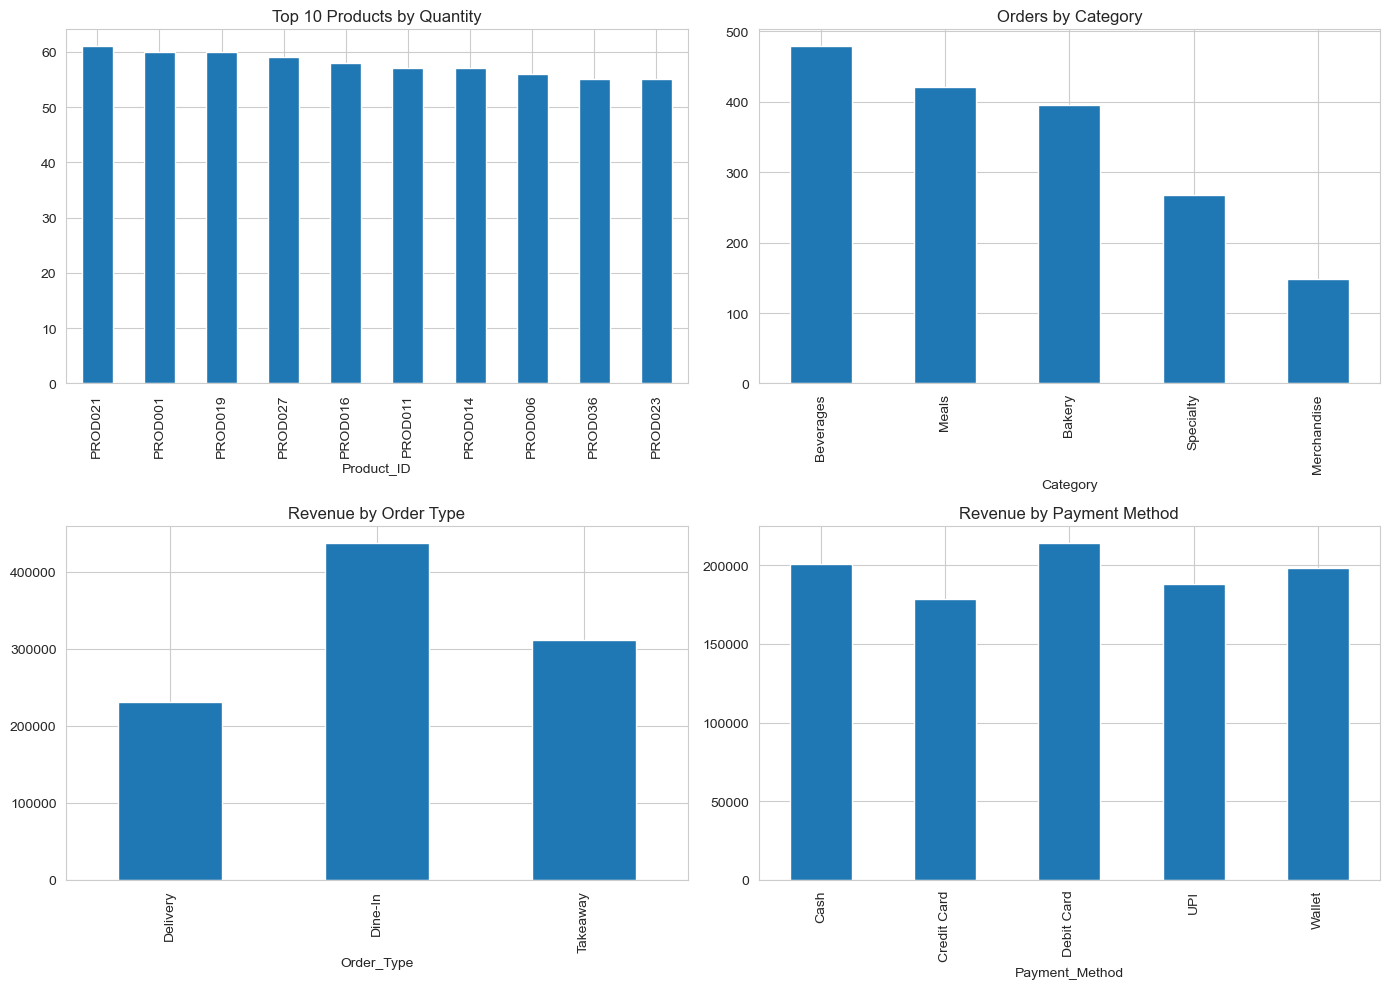

In [14]:
# 5. Sales & Menu Analysis
# 5.1 Most frequent items and categories
item_counts = orders_q2['Product_ID'].value_counts().head(10)
category_counts = orders_q2['Category'].value_counts()

# 5.2 Total revenue in Q2
total_revenue = orders_q2['Total_Amount_INR'].sum()
print(f"Total revenue Q2 2025: INR {total_revenue:,.2f}")

# 5.3 Sales trends across order types and payment methods
order_type_revenue = orders_q2.groupby('Order_Type')['Total_Amount_INR'].sum()
payment_revenue = orders_q2.groupby('Payment_Method')['Total_Amount_INR'].sum()

# 5.4 Average spend per membership tier
# Merge orders with customer tier
cust_tier = customers[['Customer_ID', 'Membership_Tier']]
orders_with_tier = orders_q2.merge(cust_tier, on='Customer_ID', how='left')
avg_spend_by_tier = orders_with_tier.groupby('Membership_Tier')['Total_Amount_INR'].mean()

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
item_counts.plot(kind='bar', ax=axes[0,0], title='Top 10 Products by Quantity')
category_counts.plot(kind='bar', ax=axes[0,1], title='Orders by Category')
order_type_revenue.plot(kind='bar', ax=axes[1,0], title='Revenue by Order Type')
payment_revenue.plot(kind='bar', ax=axes[1,1], title='Revenue by Payment Method')
plt.tight_layout()
plt.show()


In [15]:
# 6. Loyalty Campaign Analysis
# Identify customers who received a campaign reward (loyalty file)
campaign_recipients = set(loyalty['Customer_ID'].unique())
# Customers who placed orders in Q2
q2_customers = set(orders_q2['Customer_ID'].unique())
# Recipients who ordered
recipients_ordered = campaign_recipients.intersection(q2_customers)
print(f"Campaign recipients who ordered in Q2: {len(recipients_ordered)} out of {len(campaign_recipients)}")

# Compare spend of recipients vs non-recipients
customer_spend_df = customer_spend.reset_index().rename(columns={'Customer_ID': 'Customer_ID', 'Total_Amount_INR': 'Total_Spend'})
customer_spend_df['Received_Campaign'] = customer_spend_df['Customer_ID'].isin(campaign_recipients)
avg_spend_recipients = customer_spend_df[customer_spend_df['Received_Campaign']]['Total_Spend'].mean()
avg_spend_nonrecipients = customer_spend_df[~customer_spend_df['Received_Campaign']]['Total_Spend'].mean()
print(f"Avg spend recipients: INR {avg_spend_recipients:.2f}")
print(f"Avg spend non-recipients: INR {avg_spend_nonrecipients:.2f}")

# Which reward offer was most effective? (based on total spend of those who used that reward)
# From orders, column 'Reward_Applied' shows which reward was used (if any)
reward_spend = orders_q2[orders_q2['Reward_Applied'].notna()].groupby('Reward_Applied')['Total_Amount_INR'].sum().sort_values(ascending=False)
reward_avg_order = orders_q2[orders_q2['Reward_Applied'].notna()].groupby('Reward_Applied')['Total_Amount_INR'].mean().sort_values(ascending=False)
print("Total spend by reward type:\n", reward_spend)
print("Average order value by reward type:\n", reward_avg_order)

# Redemption pattern: count of orders per reward type
redemption_counts = orders_q2['Reward_Applied'].value_counts()
print("Redemption counts:\n", redemption_counts)


Campaign recipients who ordered in Q2: 140 out of 140
Avg spend recipients: INR 5620.47
Avg spend non-recipients: INR 3223.17
Total spend by reward type:
 Reward_Applied
10% Off Next Visit       136419.0
Double Loyalty Points     94270.0
Free Beverage Coupon      65491.7
Buy 1 Get 1 Beverage      51725.0
15% Off Total Bill        50498.5
Free Pastry Coupon        42680.9
Name: Total_Amount_INR, dtype: float64
Average order value by reward type:
 Reward_Applied
Double Loyalty Points    725.153846
Free Pastry Coupon       677.474603
Buy 1 Get 1 Beverage     562.228261
10% Off Next Visit       556.812245
Free Beverage Coupon     555.014407
15% Off Total Bill       424.357143
Name: Total_Amount_INR, dtype: float64
Redemption counts:
 Reward_Applied
10% Off Next Visit       245
Double Loyalty Points    130
15% Off Total Bill       119
Free Beverage Coupon     118
Buy 1 Get 1 Beverage      92
Free Pastry Coupon        63
Name: count, dtype: int64


In [16]:
# 6. Loyalty Campaign Analysis
# Identify customers who received a campaign reward (loyalty file)
campaign_recipients = set(loyalty['Customer_ID'].unique())
# Customers who placed orders in Q2
q2_customers = set(orders_q2['Customer_ID'].unique())
# Recipients who ordered
recipients_ordered = campaign_recipients.intersection(q2_customers)
print(f"Campaign recipients who ordered in Q2: {len(recipients_ordered)} out of {len(campaign_recipients)}")

# Compare spend of recipients vs non-recipients
customer_spend_df = customer_spend.reset_index().rename(columns={'Customer_ID': 'Customer_ID', 'Total_Amount_INR': 'Total_Spend'})
customer_spend_df['Received_Campaign'] = customer_spend_df['Customer_ID'].isin(campaign_recipients)
avg_spend_recipients = customer_spend_df[customer_spend_df['Received_Campaign']]['Total_Spend'].mean()
avg_spend_nonrecipients = customer_spend_df[~customer_spend_df['Received_Campaign']]['Total_Spend'].mean()
print(f"Avg spend recipients: INR {avg_spend_recipients:.2f}")
print(f"Avg spend non-recipients: INR {avg_spend_nonrecipients:.2f}")

# Which reward offer was most effective? (based on total spend of those who used that reward)
# From orders, column 'Reward_Applied' shows which reward was used (if any)
reward_spend = orders_q2[orders_q2['Reward_Applied'].notna()].groupby('Reward_Applied')['Total_Amount_INR'].sum().sort_values(ascending=False)
reward_avg_order = orders_q2[orders_q2['Reward_Applied'].notna()].groupby('Reward_Applied')['Total_Amount_INR'].mean().sort_values(ascending=False)
print("Total spend by reward type:\n", reward_spend)
print("Average order value by reward type:\n", reward_avg_order)

# Redemption pattern: count of orders per reward type
redemption_counts = orders_q2['Reward_Applied'].value_counts()
print("Redemption counts:\n", redemption_counts)

Campaign recipients who ordered in Q2: 140 out of 140
Avg spend recipients: INR 5620.47
Avg spend non-recipients: INR 3223.17
Total spend by reward type:
 Reward_Applied
10% Off Next Visit       136419.0
Double Loyalty Points     94270.0
Free Beverage Coupon      65491.7
Buy 1 Get 1 Beverage      51725.0
15% Off Total Bill        50498.5
Free Pastry Coupon        42680.9
Name: Total_Amount_INR, dtype: float64
Average order value by reward type:
 Reward_Applied
Double Loyalty Points    725.153846
Free Pastry Coupon       677.474603
Buy 1 Get 1 Beverage     562.228261
10% Off Next Visit       556.812245
Free Beverage Coupon     555.014407
15% Off Total Bill       424.357143
Name: Total_Amount_INR, dtype: float64
Redemption counts:
 Reward_Applied
10% Off Next Visit       245
Double Loyalty Points    130
15% Off Total Bill       119
Free Beverage Coupon     118
Buy 1 Get 1 Beverage      92
Free Pastry Coupon        63
Name: count, dtype: int64


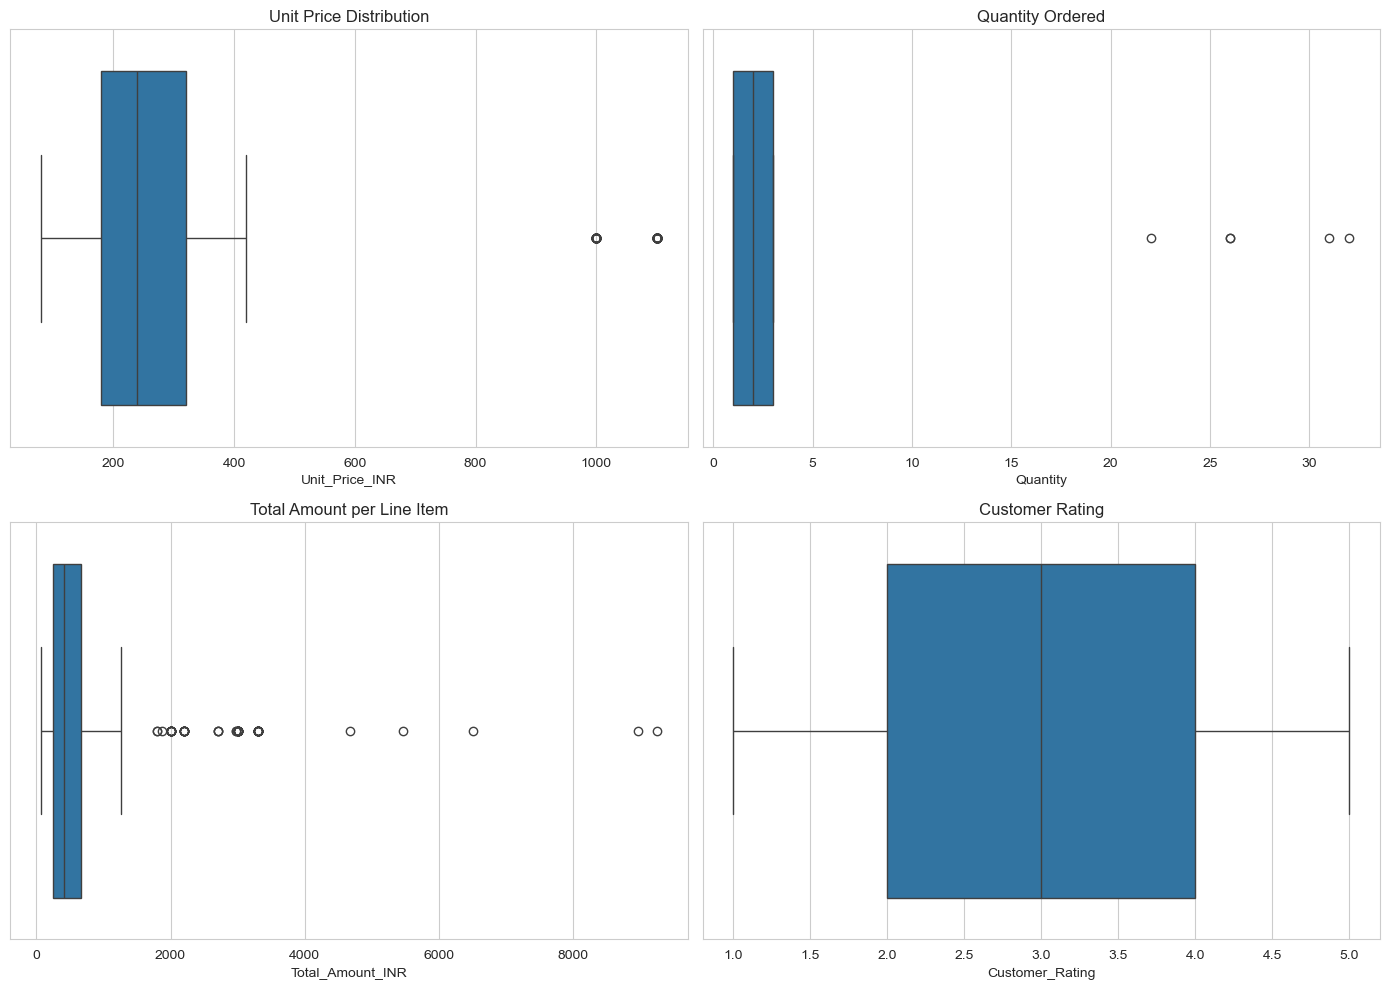

Outlier order totals (INR):
Order_ID
ORD00051    4960.0
ORD00095    4660.0
ORD00124    4250.0
ORD00152    4140.0
ORD00180    4330.0
ORD00194    5290.0
ORD00221    4780.0
ORD00250    4270.0
ORD00267    5300.0
ORD00301    6520.0
ORD00328    4530.0
ORD00348    4541.0
ORD00394    4800.0
ORD00475    4220.0
ORD00499    4110.0
ORD00619    5230.0
ORD00627    4860.0
ORD00675    4274.0
ORD00686    4422.0
ORD00695    6310.0
ORD00696    6510.0
ORD00697    4680.0
ORD00698    9240.0
ORD00699    5460.0
ORD00700    8960.0
Name: Total_Amount_INR, dtype: float64
Correlation Discount% vs Total Amount: -0.100
Correlation Quantity vs Unit Price: -0.017
Correlation matrix with rating:
                   Customer_Rating  Total_Amount_INR  Discount_%  Quantity
Customer_Rating          1.000000          0.020674    0.002700 -0.016319
Total_Amount_INR         0.020674          1.000000   -0.099110  0.677969
Discount_%               0.002700         -0.099110    1.000000  0.032758
Quantity                -0.0163

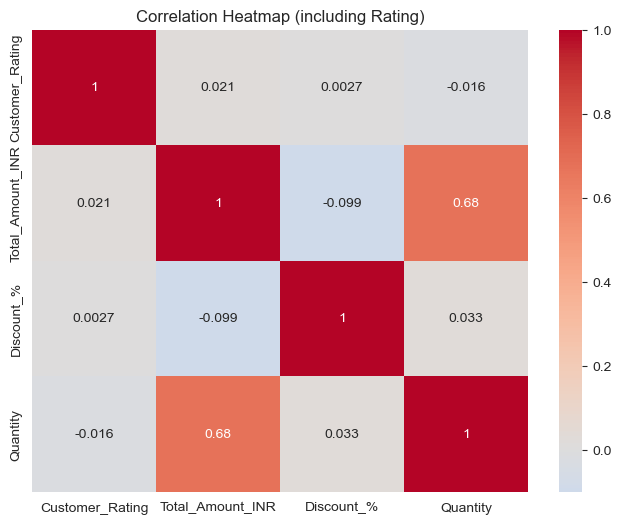

In [18]:
# 7. Advanced Analysis
# 7.1 Boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=orders_q2, x='Unit_Price_INR', ax=axes[0,0])
axes[0,0].set_title('Unit Price Distribution')
sns.boxplot(data=orders_q2, x='Quantity', ax=axes[0,1])
axes[0,1].set_title('Quantity Ordered')
sns.boxplot(data=orders_q2, x='Total_Amount_INR', ax=axes[1,0])
axes[1,0].set_title('Total Amount per Line Item')
ratings = orders_q2[orders_q2['Customer_Rating'] > 0]['Customer_Rating']
sns.boxplot(x=ratings, ax=axes[1,1])
axes[1,1].set_title('Customer Rating')
plt.tight_layout()
plt.show()


In [19]:
# 7.2 Outlier Detection (unusually large/small order amounts)
# Look at order totals (per order, not per line)
order_level = orders_q2.groupby('Order_ID')['Total_Amount_INR'].sum()
Q1 = order_level.quantile(0.25)
Q3 = order_level.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = order_level[(order_level < lower_bound) | (order_level > upper_bound)]
print(f"Outlier order totals (INR):\n{outliers}")


Outlier order totals (INR):
Order_ID
ORD00051    4960.0
ORD00095    4660.0
ORD00124    4250.0
ORD00152    4140.0
ORD00180    4330.0
ORD00194    5290.0
ORD00221    4780.0
ORD00250    4270.0
ORD00267    5300.0
ORD00301    6520.0
ORD00328    4530.0
ORD00348    4541.0
ORD00394    4800.0
ORD00475    4220.0
ORD00499    4110.0
ORD00619    5230.0
ORD00627    4860.0
ORD00675    4274.0
ORD00686    4422.0
ORD00695    6310.0
ORD00696    6510.0
ORD00697    4680.0
ORD00698    9240.0
ORD00699    5460.0
ORD00700    8960.0
Name: Total_Amount_INR, dtype: float64


Correlation Discount% vs Total Amount: -0.100
Correlation Quantity vs Unit Price: -0.017
Correlation matrix with rating:
                   Customer_Rating  Total_Amount_INR  Discount_%  Quantity
Customer_Rating          1.000000          0.020674    0.002700 -0.016319
Total_Amount_INR         0.020674          1.000000   -0.099110  0.677969
Discount_%               0.002700         -0.099110    1.000000  0.032758
Quantity                -0.016319          0.677969    0.032758  1.000000


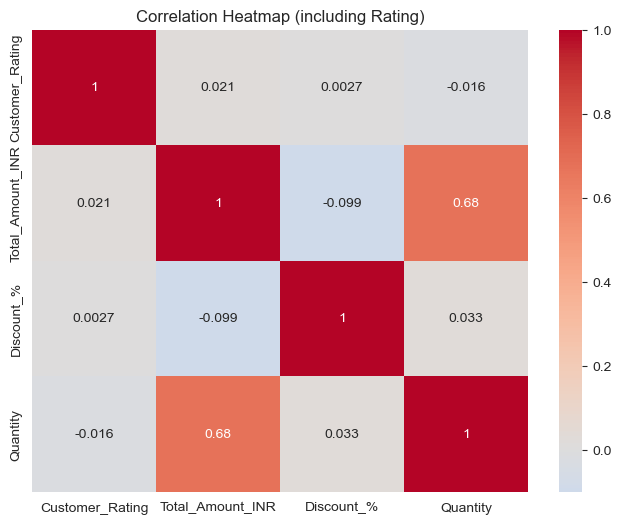

In [20]:
# 7.3 Correlation Analysis
# (a) Discount % vs Total Amount
# Use line-item level (discount applies to each line)
corr_discount_total = orders_q2[['Discount_%', 'Total_Amount_INR']].corr()
print(f"Correlation Discount% vs Total Amount: {corr_discount_total.iloc[0,1]:.3f}")

# (b) Quantity vs Unit Price
corr_qty_price = orders_q2[['Quantity', 'Unit_Price_INR']].corr()
print(f"Correlation Quantity vs Unit Price: {corr_qty_price.iloc[0,1]:.3f}")

# (c) Customer Rating vs other variables (total amount, discount%, etc.)
rating_data = orders_q2[orders_q2['Customer_Rating'] > 0][['Customer_Rating', 'Total_Amount_INR', 'Discount_%', 'Quantity']]
corr_matrix = rating_data.corr()
print("Correlation matrix with rating:\n", corr_matrix)

# Heatmap of correlations
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (including Rating)')
plt.show()